In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import linregress

In [2]:
nav = pd.read_csv("../data/processed/nav_history_clean.csv")
perf = pd.read_csv("../data/processed/scheme_performance_clean.csv")
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

In [3]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code","date"])

nav["daily_return"] = (
    nav.groupby("amfi_code")["nav"]
       .pct_change()
)

In [4]:
nav.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


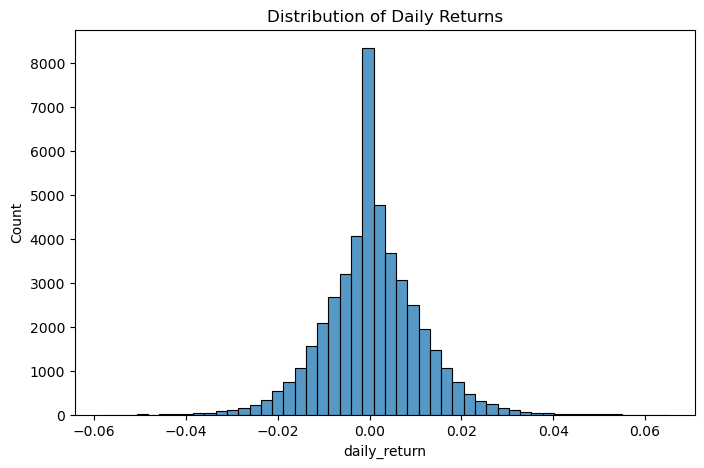

In [5]:
plt.figure(figsize=(8,5))

sns.histplot(nav["daily_return"].dropna(), bins=50)

plt.title("Distribution of Daily Returns")

plt.show()

In [7]:
nav["date"] = pd.to_datetime(nav["date"])

nav = nav.sort_values(["amfi_code", "date"])

In [8]:
def calculate_cagr(begin_nav, end_nav, years):
    return ((end_nav / begin_nav) ** (1 / years)) - 1

In [9]:
results = []

for code, group in nav.groupby("amfi_code"):

    group = group.sort_values("date")

    latest = group.iloc[-1]

    latest_date = latest["date"]

    latest_nav = latest["nav"]

    fund = {"amfi_code": code}

    for years in [1, 3, 5]:

        start_date = latest_date - pd.DateOffset(years=years)

        previous = group[group["date"] <= start_date]

        if len(previous) == 0:
            fund[f"CAGR_{years}Y"] = np.nan
            continue

        start_nav = previous.iloc[-1]["nav"]

        fund[f"CAGR_{years}Y"] = calculate_cagr(
            start_nav,
            latest_nav,
            years
        )

    results.append(fund)

In [10]:
cagr_df = pd.DataFrame(results)

In [11]:
cagr_df.head()

,amfi_code,CAGR_1Y,CAGR_3Y,CAGR_5Y
0,100016,-0.022243,0.012926,NaN
1,100025,0.037050,0.039164,NaN
2,100033,0.532324,0.324425,NaN
3,101206,0.479241,0.289677,NaN
4,101207,-0.239860,-0.041524,NaN


In [12]:
cagr_df.to_csv("../reports/cagr_table.csv", index=False)

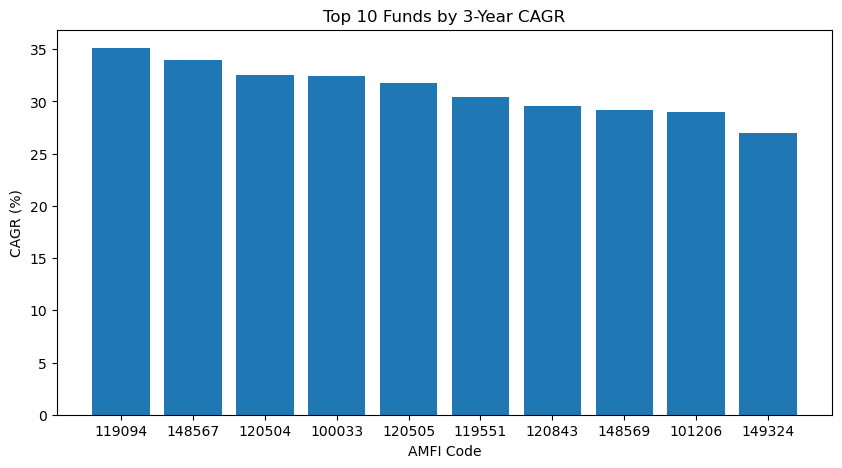

In [13]:
top10 = cagr_df.sort_values("CAGR_3Y", ascending=False).head(10)

plt.figure(figsize=(10,5))

plt.bar(top10["amfi_code"].astype(str),
        top10["CAGR_3Y"]*100)

plt.title("Top 10 Funds by 3-Year CAGR")

plt.xlabel("AMFI Code")

plt.ylabel("CAGR (%)")

plt.show()

In [14]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

In [15]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

In [16]:
sharpe_results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    mean_return = returns.mean()
    std_return = returns.std()

    sharpe = ((mean_return - daily_rf) / std_return) * np.sqrt(252)

    sharpe_results.append({
        "amfi_code": code,
        "Sharpe_Ratio": sharpe
    })

In [17]:
sharpe_df = pd.DataFrame(sharpe_results)

In [18]:
sharpe_df = sharpe_df.sort_values(
    "Sharpe_Ratio",
    ascending=False
)

sharpe_df.reset_index(drop=True, inplace=True)

sharpe_df.head()

,amfi_code,Sharpe_Ratio
0,148567,1.448291
1,120843,1.306744
2,148569,1.234930
3,119551,1.208267
4,120505,1.180101


In [19]:
sharpe_df.to_csv(
    "../reports/sharpe_ratio.csv",
    index=False
)

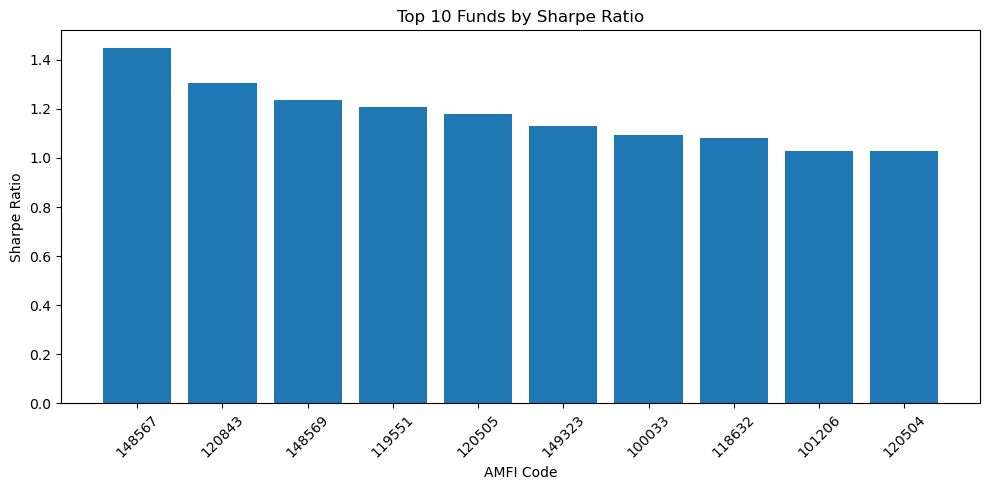

In [20]:
top10 = sharpe_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Sharpe_Ratio"]
)

plt.title("Top 10 Funds by Sharpe Ratio")

plt.xlabel("AMFI Code")

plt.ylabel("Sharpe Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [21]:
risk_free_rate = 0.065
daily_rf = risk_free_rate / 252

sortino_results = []

for code, group in nav.groupby("amfi_code"):

    returns = group["daily_return"].dropna()

    if len(returns) < 2:
        continue

    mean_return = returns.mean()

    downside_returns = returns[returns < 0]

    if len(downside_returns) == 0:
        continue

    downside_std = downside_returns.std()

    sortino = ((mean_return - daily_rf) / downside_std) * np.sqrt(252)

    sortino_results.append({
        "amfi_code": code,
        "Sortino_Ratio": sortino
    })

In [22]:
sortino_df = pd.DataFrame(sortino_results)

sortino_df = sortino_df.sort_values(
    "Sortino_Ratio",
    ascending=False
)

sortino_df.head()

,amfi_code,Sortino_Ratio
34,148567,2.385644
30,120843,2.364320
36,148569,2.146914
19,119551,2.140267
25,120505,2.029353


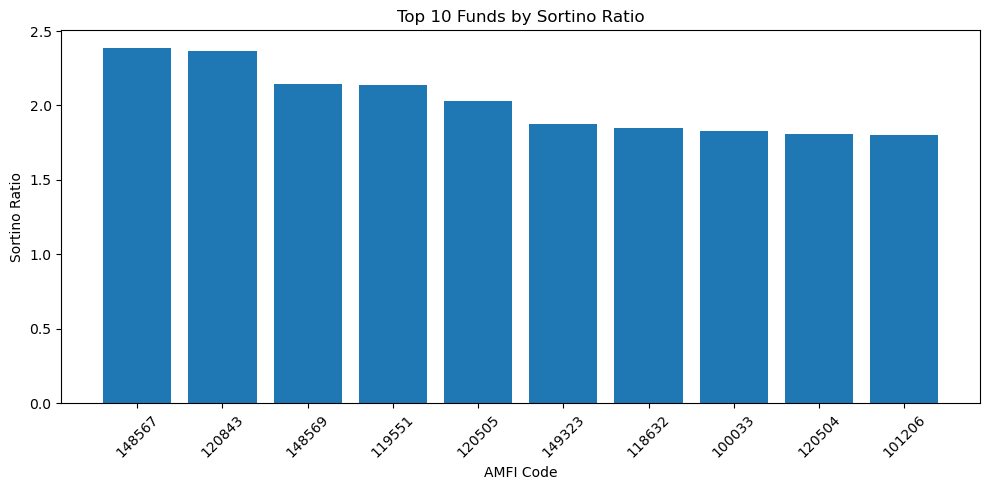

In [23]:
top10 = sortino_df.head(10)

plt.figure(figsize=(10,5))

plt.bar(
    top10["amfi_code"].astype(str),
    top10["Sortino_Ratio"]
)

plt.title("Top 10 Funds by Sortino Ratio")

plt.xlabel("AMFI Code")

plt.ylabel("Sortino Ratio")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [24]:
sortino_df.to_csv("../reports/sortino_ratio.csv", index=False)

In [25]:
from scipy.stats import linregress

In [26]:
benchmark = pd.read_csv("../data/raw/10_benchmark_indices.csv")

print(benchmark.columns.tolist())

benchmark.head()

['date', 'index_name', 'close_value']


,date,index_name,close_value
0,2022-01-03,NIFTY50,17492.79
1,2022-01-04,NIFTY50,17689.64
2,2022-01-05,NIFTY50,17835.05
3,2022-01-06,NIFTY50,17878.51
4,2022-01-07,NIFTY50,17759.15


In [27]:
benchmark["date"] = pd.to_datetime(benchmark["date"])

In [28]:
nifty100 = benchmark[
    benchmark["index_name"]=="NIFTY100"
].copy()

In [29]:
nifty100 = nifty100.sort_values("date")